## **Inladen libraries**

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import PIL
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from datetime import datetime
from tensorflow.keras.models import load_model

C:\Users\lande\AppData\Local\Temp\ipykernel_2044\3913675798.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## **Foto's inladen**

In [2]:
img_height = 224
img_width = 224
batch_size = 32

train_dataset = pd.read_csv("D:\\HHS\\Deep Learning\\Portfolio opdracht 1\\new_train.csv")

train_images = []
train_labels = []

for index, row in train_dataset.iterrows():
    img_path = os.path.join("D:\\HHS\\Deep Learning\\Portfolio opdracht 1\\new_train", f"{index}.jpg")
    img = load_img(img_path, target_size=(img_height, img_width))
    img_array = img_to_array(img)

    train_images.append(img_array)
    train_labels.append(row['Price'])

train_images = np.array(train_images)
train_labels = np.array(train_labels)

test_images = []
test_ids = []

test_csv = pd.read_csv("D:\\HHS\\Deep Learning\\Portfolio opdracht 1\\test.csv")

test_dir = "D:\\HHS\\Deep Learning\\Portfolio opdracht 1\\Test"

for index, row in test_csv.iterrows():
    img_path = os.path.join("D:\\HHS\\Deep Learning\\Portfolio opdracht 1\\Test", f"{index + 501}.jpg" )
    img = load_img(img_path, target_size=(img_height, img_width))
    img_array = img_to_array(img)

    test_images.append(img_array)
    test_ids.append(row['House ID'])

test_images = np.array(test_images)
test_ids = np.array(test_ids)


X_train, X_val, y_train, y_val = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)

## **Subset maken anders te weinig memory**

In [3]:
num_train_examples = 3000
num_val_examples =  300

X_train_subset = X_train[:num_train_examples]
y_train_subset = y_train[:num_train_examples]

X_val_subset = X_val[:num_val_examples]
y_val_subset = y_val[:num_val_examples]

## **Model Trainen**

Epoch 1/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 89s 7s/step - loss: 99.3273 - val_loss: 93.2534
Epoch 2/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - loss: 87.1759 - val_loss: 69.2866
Epoch 3/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 74.1794 - val_loss: 69.0370
Epoch 4/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 76s 6s/step - loss: 71.8769 - val_loss: 69.2679
Epoch 5/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 72.3080 - val_loss: 67.7011
Epoch 6/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 78s 7s/step - loss: 70.7589 - val_loss: 67.3844
Epoch 7/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 69.8808 - val_loss: 67.3112
Epoch 8/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 70.5152 - val_loss: 66.9538
Epoch 9/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 69.7584 - val_loss: 66.9331
Epoch 10/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 69.8291 - val_loss: 66.9840
Epoch 11/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - loss: 69.6605 - val_loss: 66.3642
Epoch 12/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step -

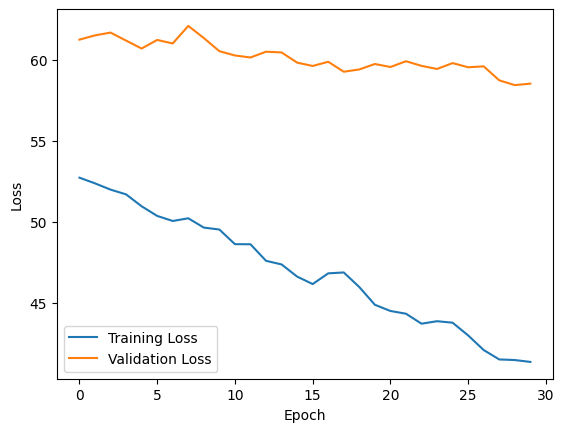

ValueError: Unable to synchronously create dataset (name already exists)

In [4]:
model = Sequential()
pretrained_model = Xception(
                    include_top=False,
                    weights="imagenet",
                    input_shape=(img_height, img_width, 3))
pretrained_model.trainable = False
model.add(pretrained_model)
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(GlobalAveragePooling2D())
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='linear'))  
model.compile(optimizer=Adam(), loss='mean_absolute_percentage_error')

history = model.fit(X_train_subset, y_train_subset, epochs=75, batch_size=256, validation_data=(X_val_subset, y_val_subset), callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)])

best_epoch_index = history.history['val_loss'].index(min(history.history['val_loss']))

best_val_loss = history.history['val_loss'][best_epoch_index]

print("Laagste validatieloss: ", best_val_loss)

plt.plot(history.history['loss'][-30:], label='Training Loss')
plt.plot(history.history['val_loss'][-30:], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

model_save_dir = "D:\\HHS\\Deep Learning\\Portfolio opdracht 1\\my_models\\"
model_name = "tf_model.h5"
model_path = os.path.join(model_save_dir, model_name)

if os.path.exists(model_path):
    base, ext = os.path.splitext(model_name)
    model_name = base + "_new.h5"
    model_path = os.path.join(model_save_dir, model_name)

model.save(model_path)
print("Model is opgeslagen op:", model_path)